# Mean-Shift PDE for Gaussian Kernel Attention

This notebook generates `fig:generative-mean-shift-pde`.  It illustrates the transport PDE
\[
\partial_t\alpha_t+\operatorname{div}(\alpha_t M_\epsilon[\alpha_t])=0,
\qquad
M_\epsilon[\alpha](x)=\epsilon\nabla\log\left(\int e^{-\|x-y\|^2/(2\epsilon)}\,d\alpha(y)\right),
\]
which is the continuous-time limit of a residual Gaussian-kernel attention / mean-shift update.  The initial law is a densely sampled mixture of three overlapping anisotropic Gaussians.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
elif not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parents[0]

sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "generative-mean-shift-pde"
out = figure_dir(NAME)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(exist_ok=True)
rng = np.random.default_rng(20260620)

We evolve particles by the mean-shift velocity.  The velocity field is recomputed on a regular grid from the current particles: the histogram is smoothed by the Gaussian kernel, differentiated as \(\epsilon\nabla\log\rho_\epsilon\), then interpolated back to particles.  This is a direct particle discretization of the transport PDE, while the rendered densities use a slightly sharper KDE only for visualization.

In [2]:
# Initial mixture: three overlapping anisotropic Gaussian components.
weights = np.array([0.34, 0.29, 0.37])
means = np.array([
    [-0.55,  0.16],
    [ 0.05, -0.23],
    [ 0.55,  0.18],
])
covs = np.array([
    [[0.25**2,  0.018], [ 0.018, 0.17**2]],
    [[0.27**2, -0.016], [-0.016, 0.20**2]],
    [[0.22**2,  0.012], [ 0.012, 0.18**2]],
])
inv_covs = np.linalg.inv(covs)
dets = np.linalg.det(covs)

# A moderately tight plotting window keeps the exported panels focused on the
# transport, while still leaving enough room for the tails of the initial KDE.
xlim = (-1.18, 1.18)
ylim = (-0.84, 0.84)
ng = 240
x_edges = np.linspace(*xlim, ng + 1)
y_edges = np.linspace(*ylim, ng + 1)
xs = 0.5 * (x_edges[:-1] + x_edges[1:])
ys = 0.5 * (y_edges[:-1] + y_edges[1:])
dx = xs[1] - xs[0]
dy = ys[1] - ys[0]
XX, YY = np.meshgrid(xs, ys)
GRID = np.stack([XX, YY], axis=-1)

# PDE bandwidth: sqrt(eps) is large enough to make the three modes communicate,
# but small enough that each mode still sharpens under the flow.
eps = 0.034
pde_sigma_px = np.sqrt(eps) / dx
render_bw = 0.066
render_sigma_px = render_bw / dx

def mixture_density(X):
    X = np.asarray(X)
    val = np.zeros(X.shape[:-1])
    for w, m, S_inv, det in zip(weights, means, inv_covs, dets):
        d = X - m
        q = np.einsum("...i,ij,...j->...", d, S_inv, d)
        val += w * np.exp(-0.5 * q) / (2 * np.pi * np.sqrt(det))
    return val

Z0 = mixture_density(GRID)


def sample_mixture_raw(n):
    comp = rng.choice(len(weights), size=n, p=weights)
    X = np.empty((n, 2))
    for k in range(len(weights)):
        idx = np.flatnonzero(comp == k)
        X[idx] = rng.multivariate_normal(means[k], covs[k], size=len(idx))
    return X


def sample_mixture(n):
    # Reject only extreme plotting-window outliers.  This keeps the vector export
    # focused on the visible high-density part of the Gaussian mixture.
    chunks = []
    total = 0
    while total < n:
        cand = sample_mixture_raw(max(2500, n - total))
        mask = (
            (cand[:, 0] > xlim[0] + 0.04) & (cand[:, 0] < xlim[1] - 0.04) &
            (cand[:, 1] > ylim[0] + 0.04) & (cand[:, 1] < ylim[1] - 0.04)
        )
        kept = cand[mask]
        chunks.append(kept)
        total += len(kept)
    return np.vstack(chunks)[:n]

n_particles = 9000
X0 = sample_mixture(n_particles)


def farthest_subset(points, m, seed=123):
    local_rng = np.random.default_rng(seed)
    chosen = [int(local_rng.integers(len(points)))]
    dist2 = np.sum((points - points[chosen[0]]) ** 2, axis=1)
    for _ in range(1, m):
        idx = int(np.argmax(dist2))
        chosen.append(idx)
        dist2 = np.minimum(dist2, np.sum((points - points[idx]) ** 2, axis=1))
    return np.asarray(chosen, dtype=int)

# Display representative trajectories from the typical part of the density,
# not from isolated Gaussian tails.
display_pool = np.flatnonzero(mixture_density(X0) > 0.050 * Z0.max())
traj_ids = display_pool[farthest_subset(X0[display_pool], 78, seed=31)]


In [3]:
def smoothed_density_from_particles(X, sigma_px):
    H, _, _ = np.histogram2d(X[:, 1], X[:, 0], bins=[y_edges, x_edges])
    rho = gaussian_filter(H.astype(float), sigma=sigma_px, mode="constant")
    mass = rho.sum() * dx * dy
    if mass > 0:
        rho = rho / mass
    return rho


def mean_shift_velocity_on_particles(X):
    rho = smoothed_density_from_particles(X, pde_sigma_px)
    log_rho = np.log(rho + 1e-14)
    grad_y, grad_x = np.gradient(log_rho, dy, dx)
    vx_grid = eps * grad_x
    vy_grid = eps * grad_y
    interp_vx = RegularGridInterpolator((ys, xs), vx_grid, bounds_error=False, fill_value=0.0)
    interp_vy = RegularGridInterpolator((ys, xs), vy_grid, bounds_error=False, fill_value=0.0)
    query = np.column_stack([X[:, 1], X[:, 0]])
    return np.column_stack([interp_vx(query), interp_vy(query)])

# Integrate the PDE.  The snapshots are deliberately front-loaded: they show the
# transient sharpening before mean shift fully concentrates each mode.
T = 2.85
steps = 190
dt = T / steps
snapshot_times = np.array([0.32, 0.72, 1.30, 2.45])
snapshot_steps = np.round(snapshot_times / dt).astype(int)
record_stride = 3
max_speed = 1.10

X = X0.copy()
trajectory = []
snapshots = {}
for k in range(steps + 1):
    if k % record_stride == 0:
        trajectory.append(X[traj_ids].copy())
    if k in snapshot_steps:
        snapshots[int(k)] = X.copy()
    if k == steps:
        break
    V = mean_shift_velocity_on_particles(X)
    speed = np.linalg.norm(V, axis=1)
    scale = np.minimum(1.0, max_speed / np.maximum(speed, 1e-12))
    X = X + dt * V * scale[:, None]
    # Keep rare boundary particles inside the rendering box; the displayed flow
    # stays far from the boundary for this example.
    X[:, 0] = np.clip(X[:, 0], xlim[0] + 1e-3, xlim[1] - 1e-3)
    X[:, 1] = np.clip(X[:, 1], ylim[0] + 1e-3, ylim[1] - 1e-3)

trajectory = np.asarray(trajectory)  # time, selected particle, coordinate
snapshot_rhos = {k: smoothed_density_from_particles(v, render_sigma_px) for k, v in snapshots.items()}
assert len(snapshot_rhos) == len(snapshot_times)


In [4]:
def time_cmap(t):
    color = interp_color(float(t))
    return LinearSegmentedColormap.from_list(
        "time-cmap",
        [(1, 1, 1, 1), (*color, 0.16), (*color, 1.0)],
    )


def format_axis(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_initial_density(ax):
    levels = np.linspace(0.10 * Z0.max(), 0.92 * Z0.max(), 8)
    ax.contourf(XX, YY, Z0, levels=levels, cmap="Reds", alpha=0.24, antialiased=True)
    ax.contour(XX, YY, Z0, levels=levels[1::2], colors=RED, linewidths=0.34, alpha=0.48)


def draw_trajectories(ax):
    draw_initial_density(ax)
    n_t = trajectory.shape[0]
    segments = []
    colors = []
    for i in range(trajectory.shape[1]):
        pts = trajectory[:, i, :]
        for k in range(n_t - 1):
            segments.append([pts[k], pts[k + 1]])
            colors.append((*interp_color(k / max(n_t - 2, 1)), 0.46))
    lc = LineCollection(segments, colors=colors, linewidths=0.48, zorder=3)
    ax.add_collection(lc)
    ax.scatter(trajectory[0, :, 0], trajectory[0, :, 1], s=2.9, color=RED, edgecolor="none", alpha=0.70, zorder=4)
    ax.scatter(trajectory[-1, :, 0], trajectory[-1, :, 1], s=2.9, color=BLUE, edgecolor="none", alpha=0.86, zorder=5)
    format_axis(ax)


def draw_density_snapshot(ax, rho, t):
    # Each time uses its own robust color range so the reader sees the evolving
    # shape rather than only the increasing peak height.
    vmax = np.quantile(rho[rho > 0], 0.992)
    visible = np.where(rho < 0.008 * vmax, 0.0, np.clip(rho, 0.0, vmax))
    ax.imshow(
        visible,
        extent=[*xlim, *ylim],
        origin="lower",
        cmap=time_cmap(t / T),
        vmin=0.0,
        vmax=vmax,
        interpolation="bilinear",
    )
    levels = np.linspace(0.20 * vmax, 0.80 * vmax, 4)
    ax.contour(xs, ys, rho, levels=levels, colors="#303030", linewidths=0.30, alpha=0.32)
    format_axis(ax)

# Individual PDF panels for LaTeX layout.
fig, ax = plt.subplots(figsize=(2.45, 2.45))
draw_trajectories(ax)
save_pdf(fig, out / "trajectories.pdf", pad_inches=0.015)
plt.close(fig)

ordered_steps = list(snapshot_rhos.keys())
for idx, (step, t) in enumerate(zip(ordered_steps, snapshot_times), start=1):
    fig, ax = plt.subplots(figsize=(1.18, 1.18))
    draw_density_snapshot(ax, snapshot_rhos[step], t)
    save_pdf(fig, out / f"snapshot-{idx}.pdf", pad_inches=0.010)
    plt.close(fig)

# Compact thumbnail/contact sheet for the figure gallery and MyST page.
fig = plt.figure(figsize=(6.2, 2.05))
gs = fig.add_gridspec(2, 3, width_ratios=[1.35, 0.72, 0.72], wspace=0.032, hspace=0.032)
ax = fig.add_subplot(gs[:, 0])
draw_trajectories(ax)
for idx, (step, t) in enumerate(zip(ordered_steps, snapshot_times)):
    ax = fig.add_subplot(gs[idx // 2, 1 + idx % 2])
    draw_density_snapshot(ax, snapshot_rhos[step], t)
fig.savefig(thumb_dir / f"{NAME}.png", dpi=230, bbox_inches="tight", pad_inches=0.030)
plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

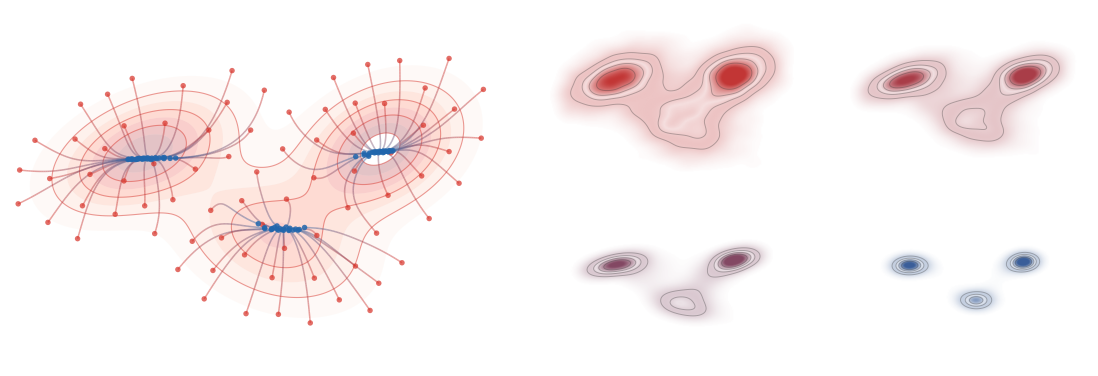

In [5]:
from IPython.display import Image, display
_thumb = Path("thumbnails/generative-mean-shift-pde.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/generative-mean-shift-pde.png")
display(Image(filename=str(_thumb)))